# Optimizacion de funciones

In [1]:
import sympy as sp
import numpy as np
import matplotlib.pyplot as plt

In [3]:
# Vamos a crear las variables symbolicas
x, y = sp.symbols('x y')
# Defino la funcion a optimizar
f = x**2 + y**2 - 4*x - 2*y + 5
# calculo el gradiente de la funcion
grad_f = [sp.diff(f, var) for var in (x, y)]
# Calculo los puntos criticos
critical_points = sp.solve(grad_f, (x, y))
# muestro resultados
print(f)
print("Gradiente:", grad_f)
print("Puntos criticos:", critical_points) 




x**2 - 4*x + y**2 - 2*y + 5
Gradiente: [2*x - 4, 2*y - 2]
Puntos criticos: {x: 2, y: 1}


In [5]:
# Tecnica de optimizacion: Gradiente descendente
# Defino la funcion de gradiente descendente
def gradient_descent(f_grad, initial_point, learning_rate,iterations):
    f_grad_funcs = [sp.lambdify((x, y), grad) for grad in f_grad]
    point = np.array(initial_point, dtype=float)
    points = [point]
    for _ in range(iterations):
        grad_values = np.array([grad(*point) for grad in f_grad_funcs])
        point = point-learning_rate * grad_values
        points.append(point.copy())
    return np.array(points)

In [8]:
# Configuro el metodo del descenso del gradiente
initial_point = [0, 0] # punto de inicio
learning_rate = 0.1
iterations = 50

# Ejecuto el metodo del descenso del gradiente
points = gradient_descent(grad_f, initial_point, learning_rate, iterations)

ImportError: dlopen(/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/contourpy/_contourpy.cpython-313-darwin.so, 0x0002): tried: '/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/contourpy/_contourpy.cpython-313-darwin.so' (mach-o file, but is an incompatible architecture (have 'x86_64', need 'arm64e' or 'arm64')), '/System/Volumes/Preboot/Cryptexes/OS/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/contourpy/_contourpy.cpython-313-darwin.so' (no such file), '/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/contourpy/_contourpy.cpython-313-darwin.so' (mach-o file, but is an incompatible architecture (have 'x86_64', need 'arm64e' or 'arm64'))

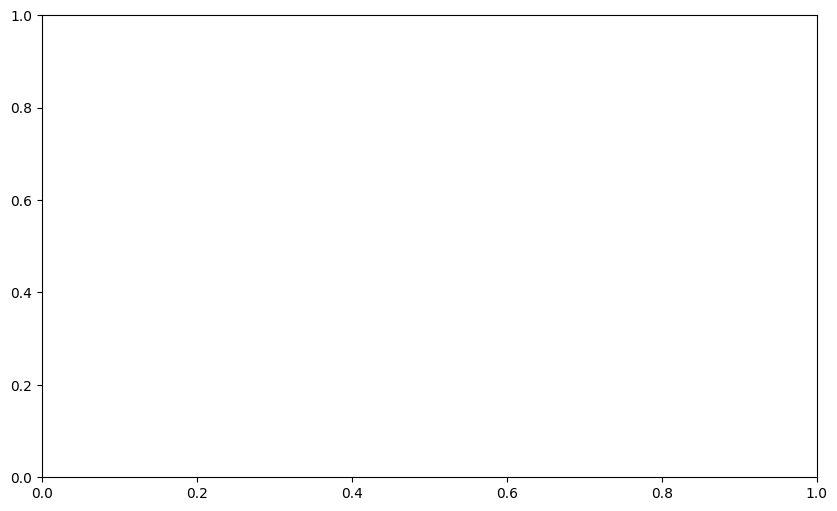

In [15]:
# grafico la funcion y el descenso del gradiente
x_vals = np.linspace(-1, 5, 400)
y_vals = np.linspace(-1, 3, 400)
X, Y = np.meshgrid(x_vals, y_vals)
Z = X**2 + Y**2 - 4*X - 2*Y + 5

plt.figure(figsize=(10, 6))

contour = plt.contour(X, Y, Z, levels=50)
plt.clabel(contour, inline=1, fontsize=10)
plt.plot(points[:, 0], points[:, 1], 'ro-',label ='Puntos de Descenso')
plt.title("Optimizacion usando el descenso del Gradiente")
plt.xlabel("x")
plt.ylabel("y")
plt.grid()
plt.legend()
plt.show()